# Chandra/HETG observation of Vela X-1 (2001) — detector-space analysis

BLiSS applied to the Chandra HETG spectrum of Vela X-1 (ObsID 1927) loaded directly
from the OGIP files. HEG and MEG are analysed separately: they have different
resolutions and effective-area curves, so combining them would average two responses.

The ±1 orders of each arm were combined with CIAO:

    combine_spectra src_spectra="heg_-1.pha.gz,heg_1.pha.gz" outroot=heg \
        src_arfs="heg_-1.arf.gz,heg_1.arf.gz" src_rmfs="heg_-1.rmf.gz,heg_1.rmf.gz" \
        method=sum clobber=yes

In this mode BLiSS rebins the spectrum conserving counts, works in counts s⁻¹ keV⁻¹,
and calibrates every candidate against line-free spectra drawn as Poisson counts at
channel resolution and pushed through the same rebinning and baseline estimation as
the data. A companion notebook (`vela_x1_2001_dat.ipynb`) runs the same object from a
plain text spectrum, for comparison.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bliss import *
from bliss.line_search.blind_line_search import prepare_spectrum

## 1. Input files, output folder and energy range

In [2]:
chandra_path = Path("obs_1927_tgid_4659")

heg_pha = chandra_path / "heg.pha"
heg_rmf = chandra_path / "heg.rmf"
heg_arf = chandra_path / "heg.arf"

meg_pha = chandra_path / "meg.pha"
meg_rmf = chandra_path / "meg.rmf"
meg_arf = chandra_path / "meg.arf"

output_dir = Path("results_vela_x1_2001_pha")
output_dir.mkdir(exist_ok=True)

# Energy range used throughout
en1, en2 = 0.5, 8.5

## 2. Load and inspect the HEG spectrum

`prepare_spectrum` is the function the pipeline uses internally. With
`rebin_method="none"` it returns the spectrum at native channel resolution, already
converted to counts s⁻¹ keV⁻¹. The `.native` attribute keeps the channel-level counts
and exposure used later for the Poisson null.

channels      : 8192
exposure [s]  : 58862.078930584
median ΔE [eV]: 0.2453923225402832


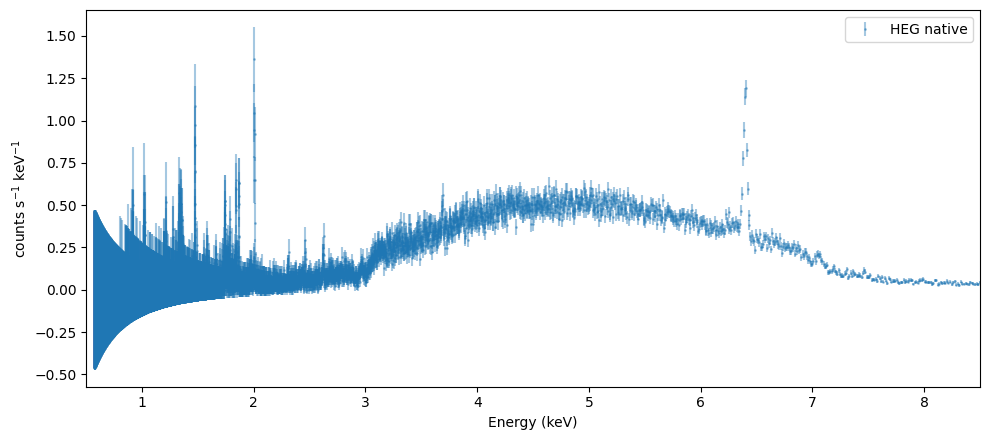

In [3]:
heg_native = prepare_spectrum(heg_pha, heg_rmf, heg_arf, rebin_method="none")

print("channels      :", len(heg_native.energy))
print("exposure [s]  :", heg_native.native.exposure)
print("median ΔE [eV]:", 1e3 * np.median(heg_native.bin_width))

plt.figure(figsize=(10, 4.5))
plt.errorbar(heg_native.energy, heg_native.values, yerr=heg_native.uncertainties,
             fmt=".", ms=2, alpha=0.4, label="HEG native")
plt.xlim(en1, en2)
plt.xlabel("Energy (keV)")
plt.ylabel("counts s$^{-1}$ keV$^{-1}$")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Rebin the spectrum conserving counts

Three schemes are available (`rebin_method`): `"bins"` groups a fixed number of
channels, `"resolution"` uses fixed-width intervals in keV, and `"snr"` accumulates
channels until a signal-to-noise threshold. All of them **sum** counts, so the result
stays Poisson. We use a fixed resolution of 3 eV. The same scheme will be applied to
every synthetic null realization inside the pipeline.

In [4]:
rebin_method = "resolution"
rebin_scale = 0.003   # keV

heg = prepare_spectrum(heg_pha, heg_rmf, heg_arf,
                                rebin_method=rebin_method, rebin_scale=rebin_scale)

counts_per_bin = heg.values * heg.native.exposure * heg.bin_width
print("bins after rebinning:", len(heg.energy))
print("median counts/bin   :", np.median(counts_per_bin))

bins after rebinning: 1979
median counts/bin   : 28.0


### 3.1 Empirical baseline

The baseline is a running median in physical energy units (`baseline_window`, default
0.4 keV). It is the line-free model from which the Poisson null spectra are drawn.

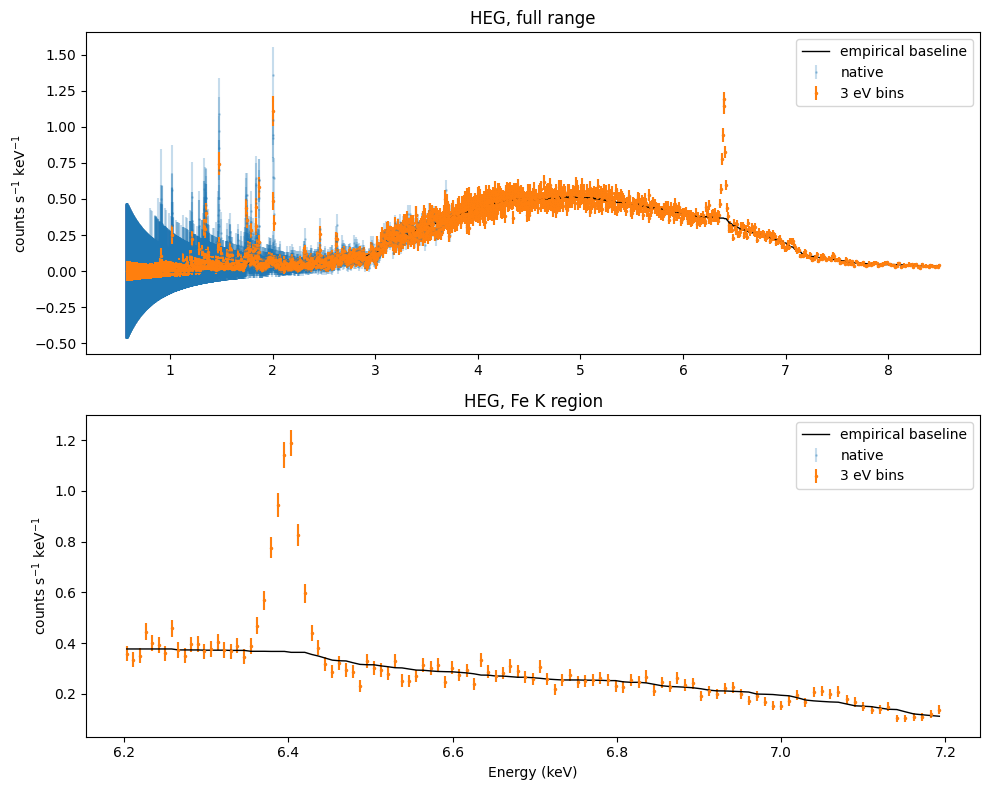

In [5]:
baseline_heg = base_calculator(heg.energy, heg.values)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for ax, xlim, title in zip(axes, [(en1, en2), (6.2, 7.2)], ["full range", "Fe K region"]):
    m0 = (heg_native.energy >= xlim[0]) & (heg_native.energy <= xlim[1])
    m1 = (heg.energy >= xlim[0]) & (heg.energy <= xlim[1])
    ax.errorbar(heg_native.energy[m0], heg_native.values[m0], yerr=heg_native.uncertainties[m0],
                fmt=".", ms=2, alpha=0.25, label="native")
    ax.errorbar(heg.energy[m1], heg.values[m1], yerr=heg.uncertainties[m1],
                fmt=".", ms=3, label=f"{1e3*rebin_scale:.0f} eV bins")
    ax.plot(heg.energy[m1], baseline_heg[m1], "k-", lw=1, label="empirical baseline")
    ax.set_title(f"HEG, {title}")
    ax.set_ylabel("counts s$^{-1}$ keV$^{-1}$")
    ax.legend()
axes[1].set_xlabel("Energy (keV)")
plt.tight_layout()
plt.show()

## 4. Candidate search (HEG)

`find_candidate_lines` takes the PHA/RMF/ARF paths and the rebinning scheme, so that
the null realizations follow exactly the same chain as the data.
`num_synthetic_simulations` sets the number of null spectra.

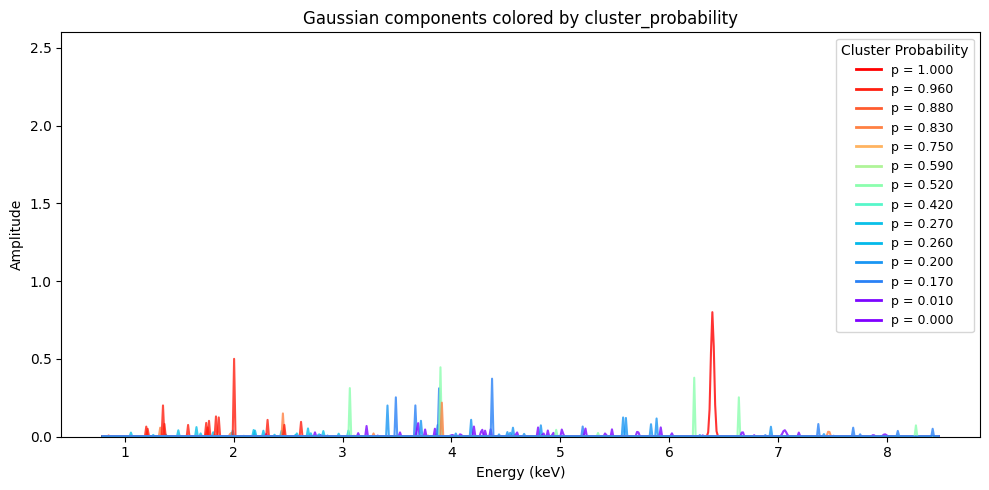

,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,0.857728,0.000012,0.000270,0.000000e+00,0.011452,0.010556,1.000000,0.048213,0.011452,0.000000,0.237536,1.084921e+00,0.000008,0.000007,1.084921e+00,NaN,0.88
1,0.851689,0.000013,0.000266,1.463915e-53,0.011615,0.010556,1.000000,0.048213,0.011615,0.000000,0.240915,1.100351e+00,0.000008,0.000007,1.100351e+00,NaN,0.88
2,0.875674,0.000020,0.000280,0.000000e+00,0.017349,0.011945,1.000000,0.047120,0.017349,0.000000,0.368189,1.452385e+00,0.000012,0.000008,1.452385e+00,NaN,0.88
3,0.905705,0.000623,0.000299,9.780494e-05,0.040542,0.000029,0.781208,0.047010,0.045654,0.005608,0.862422,1.381761e+03,0.000030,0.000010,3.061228e+00,5.425745,0.96
4,0.914699,0.001469,0.000308,1.043487e-04,0.100892,0.000063,0.898811,0.047888,0.106303,0.005665,2.106855,1.598667e+03,0.000078,0.000026,2.954096e+00,13.761496,0.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,7.874771,0.011445,0.010122,1.168299e-02,0.011736,0.011596,0.083368,0.009662,0.057014,0.048239,1.214602,1.012019e+00,0.000298,0.000452,6.581633e-01,6.172831,0.01
220,7.980265,0.004249,0.015988,4.253665e-03,0.015917,0.003664,0.120902,0.009620,0.058220,0.045661,1.654656,4.344205e+00,0.000638,0.000224,2.842446e+00,13.970643,0.01
221,8.103538,7.084242,0.003321,8.425309e+02,0.079562,80236.020089,0.110481,0.008872,0.055263,0.044267,8.967403,9.916005e-07,0.000662,688.679188,9.616331e-07,14.960427,0.17
222,8.266050,191.558566,0.003400,7.649068e+02,0.073025,67169.748179,0.134840,0.008279,0.050479,0.038483,8.820964,1.087169e-06,0.000622,589.323775,1.056041e-06,16.171983,0.52


In [6]:
N_SIM = 10
SEED = 1

heg_candidates = find_candidate_lines(
    pha=heg_pha, rmf=heg_rmf, arf=heg_arf,
    rebin_method=rebin_method, rebin_scale=rebin_scale,
    en1=en1, en2=en2,
    num_synthetic_simulations=N_SIM, synthetic_seed=SEED,
    output_dir=output_dir)

plot_line_prob(heg_candidates)
heg_candidates

## 5. Filter candidates and perform a global fit (HEG)

Candidates are kept if they pass a cluster-probability threshold, at least one
significance criterion, and a minimum relative contribution. The global
multi-Gaussian fit is done on the same rebinned spectrum used for the search.

In [8]:
P_MIN = 0.8      # minimum cluster probability (0-1)
REL_POWER_MIN = 0  # minimum relative contribution of the line (0-1)
SNR_PEAK_MIN = 0    # a line is kept if at least one S/N criterion is met
SNR_AREA_MIN = 0
SNR_AMPLITUDE_MIN = 0

lines_pd = heg_candidates
clean_mask = (
    (lines_pd["cluster_probability"] >= P_MIN)
    & (
        (lines_pd["snr_peak"] >= SNR_PEAK_MIN)
        | (lines_pd["snr_area"] >= SNR_AREA_MIN)
        | (lines_pd["snr_amplitude"] >= SNR_AMPLITUDE_MIN)
    )
    & (lines_pd["relative_power"] >= REL_POWER_MIN)
)
heg_lines = lines_pd.loc[clean_mask].reset_index(drop=True)
print(f"{len(heg_lines)} of {len(lines_pd)} candidates kept")

44 of 224 candidates kept


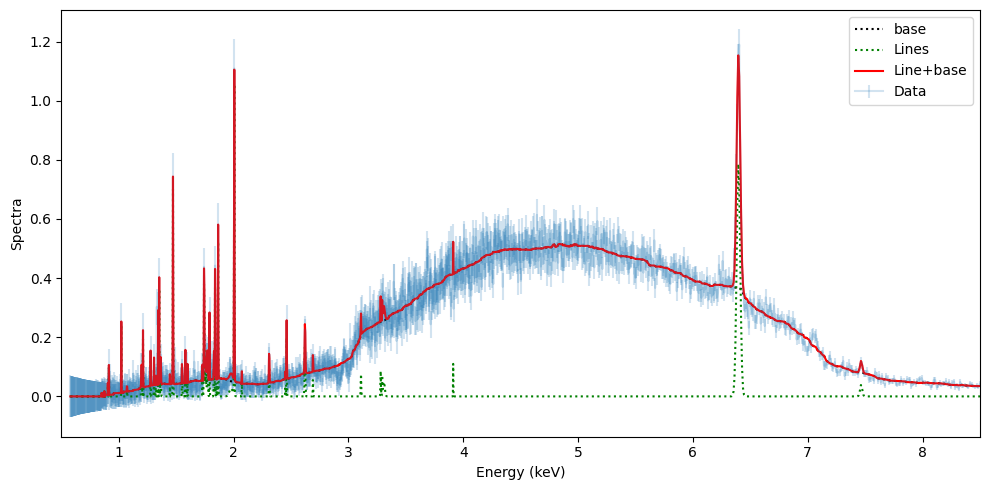

In [9]:
heg_lines_global = fit_global(
    heg_lines,
    heg,
    energy_min=en1, energy_max=en2,
    output_dir=output_dir,
)

## 6. Identify emission lines within a Doppler velocity window (HEG)

Fitted centroids are compared with a reference list of transitions. A line is
tentatively identified when its energy is consistent with a transition within the
chosen velocity window.

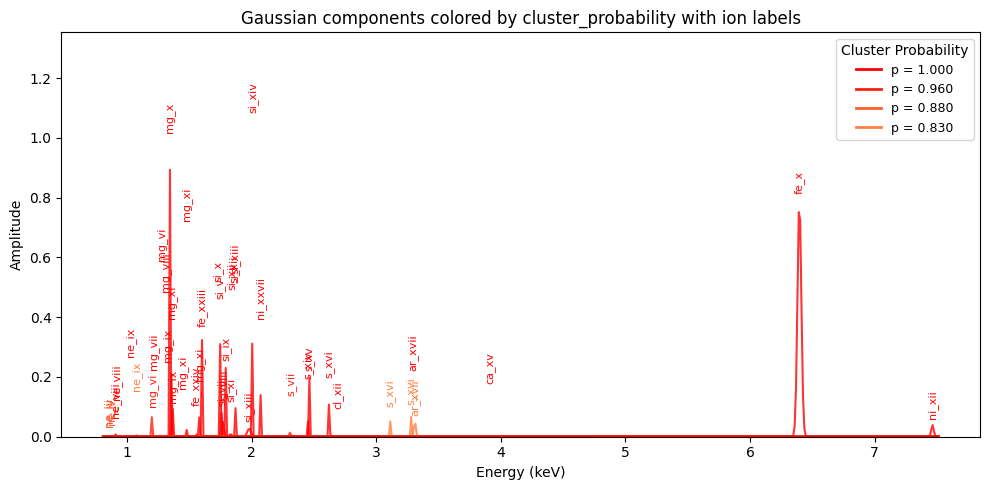

,ion,doppler_kms,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,ne_iv,394.926143,0.857728,0.000058,0.000270,0.000000e+00,0.011452,4.908107e-02,1.000000,0.048213,0.011452,0.000000,0.237536,2.333352e-01,0.000008,0.000033,2.333352e-01,NaN,0.88
1,ne_iii,11.160230,0.851689,0.000061,0.000266,4.712529e-53,0.011615,4.977911e-02,1.000000,0.048213,0.011615,0.000000,0.240915,2.333352e-01,0.000008,0.000033,2.333352e-01,NaN,0.88
2,ne_v,302.549871,0.875674,0.000081,0.000280,5.415049e-48,0.017349,4.903604e-02,1.000000,0.047120,0.017349,0.000000,0.368189,3.538000e-01,0.000012,0.000034,3.538000e-01,NaN,0.88
3,ne_viii,-377.875128,0.905704,0.002336,0.000299,3.665037e-04,0.040542,1.098582e-04,0.781208,0.047010,0.045654,0.005608,0.862422,3.690437e+02,0.000030,0.000037,8.162471e-01,21.258771,1.00
4,ne_viii,52.143062,0.914699,0.002322,0.000305,1.649996e-04,0.100893,9.866965e-05,0.898811,0.047888,0.106303,0.005665,2.106857,1.022528e+03,0.000077,0.000042,1.847861e+00,53.943515,1.00
5,ne_ix,284.745599,1.023015,0.001771,0.001171,8.095327e-04,0.247242,1.080465e-01,0.912618,0.046039,0.253142,0.011565,5.370282,2.288296e+00,0.000726,0.000593,1.222492e+00,61.681151,1.00
6,ne_ix,-401.540773,1.072297,2.372139,0.000744,2.987276e+02,0.132973,2.190268e+05,0.340638,0.040949,0.033914,0.016680,3.247271,6.071074e-07,0.000248,420.454109,5.898381e-07,NaN,0.83
7,mg_vi,-574.482000,1.199095,0.001667,0.002825,1.559298e-03,0.079915,4.322956e-02,0.551069,0.042765,0.099524,0.028806,1.868720,1.848624e+00,0.000566,0.000437,1.293901e+00,18.984254,0.96
8,mg_vii,-595.052703,1.212049,0.001703,0.001209,8.911964e-04,0.203241,1.173654e-01,0.762114,0.042765,0.223815,0.030215,4.752546,1.731695e+00,0.000616,0.000577,1.067696e+00,18.967900,1.00
9,mg_vi,350.456210,1.278904,116.144222,0.000682,1.435060e+02,0.566441,5.443688e+05,0.616037,0.039846,0.154831,0.036787,14.215722,1.040546e-06,0.000969,953.204483,1.016494e-06,9.506464,1.00


In [10]:
max_doppler_velocity = 600  # km/s

heg_lines_ion = add_most_probable_ion(heg_lines_global, max_doppler_velocity)
plot_line_prob(heg_lines_ion)
heg_lines_ion

In [11]:
# All transitions compatible with each line within the velocity window
compatible_heg = get_all_compatible_lines(heg_lines_global, max_doppler_velocity)
compatible_heg[0].head()

,ion,energy_keV,doppler_kms
0,ne_iv,0.856599,394.926143
1,ne_iv,0.856659,374.181481
2,ne_vii,0.856304,498.622341
3,ne_v,0.857844,-40.599685
4,ne_v,0.857785,-19.842422


## 7. MEG

The MEG arm has more effective area below ~2 keV but half the resolution of HEG and
almost no counts above ~5 keV. The procedure is identical.

channels: 8192  bins: 1520  exposure [s]: 58862.078930584


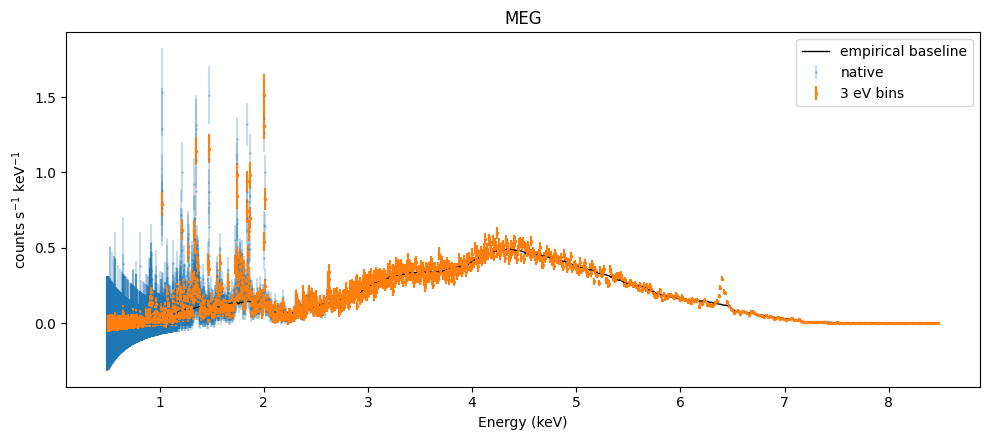

In [12]:
meg_native = prepare_spectrum(meg_pha, meg_rmf, meg_arf, rebin_method="none")
meg = prepare_spectrum(meg_pha, meg_rmf, meg_arf,
                                rebin_method=rebin_method, rebin_scale=rebin_scale)
baseline_meg = base_calculator(meg.energy, meg.values)

print("channels:", len(meg_native.energy), " bins:", len(meg.energy),
      " exposure [s]:", meg.native.exposure)

m0 = (meg_native.energy >= en1) & (meg_native.energy <= en2)
m1 = (meg.energy >= en1) & (meg.energy <= en2)
plt.figure(figsize=(10, 4.5))
plt.errorbar(meg_native.energy[m0], meg_native.values[m0], yerr=meg_native.uncertainties[m0],
             fmt=".", ms=2, alpha=0.25, label="native")
plt.errorbar(meg.energy[m1], meg.values[m1], yerr=meg.uncertainties[m1],
             fmt=".", ms=3, label=f"{1e3*rebin_scale:.0f} eV bins")
plt.plot(meg.energy[m1], baseline_meg[m1], "k-", lw=1, label="empirical baseline")
plt.xlabel("Energy (keV)")
plt.ylabel("counts s$^{-1}$ keV$^{-1}$")
plt.title("MEG")
plt.legend()
plt.tight_layout()
plt.show()

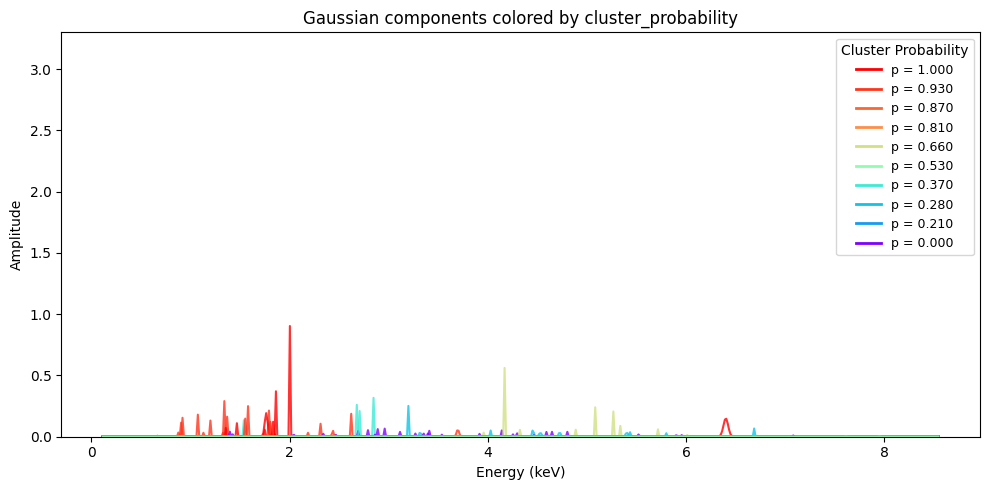

,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,0.557989,2.750660e+08,0.000397,3.193762e+07,0.005638,73458.085075,1.000000,0.051828,0.005638,0.000000,0.108776,7.674583e-08,5.604350e-06,451322.372113,1.241762e-11,NaN,0.81
1,0.569981,4.620241e+06,0.000417,6.410284e+05,0.022552,4461.113591,1.000000,0.051335,0.022552,0.000000,0.439303,5.055183e-06,2.358120e-05,36236.594314,6.507565e-10,NaN,0.81
2,0.668776,1.450734e-03,0.003972,1.463211e-03,0.009838,0.003134,1.000000,0.043690,0.011073,0.000000,0.225189,3.138985e+00,9.795878e-05,0.000048,2.053331e+00,NaN,0.81
3,0.728742,1.166679e-03,0.002253,9.875414e-04,0.011816,0.004778,0.499485,0.040725,0.016991,0.005671,0.290134,2.472662e+00,6.672058e-05,0.000040,1.676648e+00,11.764229,0.53
4,0.743277,0.000000e+00,0.000031,0.000000e+00,0.007660,0.000000,0.649795,0.040992,0.027182,0.005770,0.186859,NaN,5.979812e-07,0.000000,NaN,0.103639,0.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,6.790912,0.000000e+00,0.004829,0.000000e+00,0.000003,0.000000,-0.049289,0.006832,0.048509,0.053538,0.000504,NaN,4.170885e-08,0.000000,NaN,0.000779,0.21
150,7.077645,4.185874e+03,0.002813,4.102644e+03,0.015777,481.713923,0.153483,0.005761,0.034508,0.025325,2.738767,3.275247e-05,1.112472e-04,162.286409,6.854994e-07,4.392837,0.00
151,7.609560,3.316084e-02,0.010044,5.272367e-02,0.002108,0.013892,0.202952,0.002316,0.004355,0.002886,0.910300,1.517730e-01,5.308689e-05,0.000447,1.187080e-01,18.396195,0.53
152,7.947773,6.211084e-03,0.012820,4.055469e-02,0.002230,0.007066,0.344758,0.001716,0.002659,0.001296,1.299548,3.156119e-01,7.166655e-05,0.000321,2.233512e-01,55.311176,0.53


In [13]:
meg_candidates = find_candidate_lines(
    pha=meg_pha, rmf=meg_rmf, arf=meg_arf,
    rebin_method=rebin_method, rebin_scale=rebin_scale,
    en1=en1, en2=en2,
    num_synthetic_simulations=N_SIM, synthetic_seed=SEED,
    output_dir=output_dir,
)
plot_line_prob(meg_candidates)
meg_candidates

In [14]:
lines_pd = meg_candidates
clean_mask = (
    (lines_pd["cluster_probability"] >= P_MIN)
    & (
        (lines_pd["snr_peak"] >= SNR_PEAK_MIN)
        | (lines_pd["snr_area"] >= SNR_AREA_MIN)
        | (lines_pd["snr_amplitude"] >= SNR_AMPLITUDE_MIN)
    )
    & (lines_pd["relative_power"] >= REL_POWER_MIN)
)
meg_lines = lines_pd.loc[clean_mask].reset_index(drop=True)
print(f"{len(meg_lines)} of {len(lines_pd)} candidates kept")

47 of 154 candidates kept


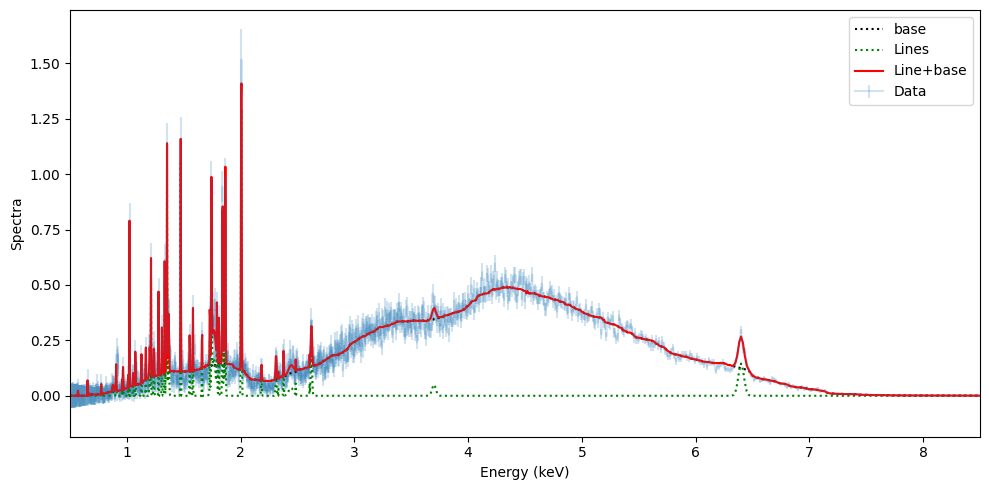

In [15]:
meg_lines_global = fit_global(
    meg_lines,
    meg,
    energy_min=en1, energy_max=en2,
    output_dir=output_dir,
)

In [16]:
meg_lines_global

,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,0.571165,0.033513,0.001192,0.060385,0.036937,2.877841e+00,1.000000,0.051828,0.005638,0.000000,0.712698,1.283512e-02,0.000110,0.010258,1.076092e-02,NaN,0.81
1,0.653847,73.136313,0.000575,15.716481,0.072495,2.850130e+03,1.000000,0.051335,0.022552,0.000000,1.412179,2.543555e-05,0.000104,5.001839,2.088166e-05,NaN,0.81
2,0.669089,0.018230,0.004501,0.018328,0.009425,3.317206e-02,1.000000,0.043690,0.011073,0.000000,0.215722,2.841188e-01,0.000106,0.000572,1.857960e-01,2.973472,0.81
3,0.773690,0.002479,0.001868,0.001745,0.047247,4.543634e-02,0.798011,0.039644,0.052749,0.005926,1.191782,1.039849e+00,0.000221,0.000297,7.459828e-01,36.632378,1.00
4,0.877935,0.005426,0.006067,0.005320,0.031745,2.550939e-02,0.468687,0.038415,0.049418,0.017877,0.826380,1.244443e+00,0.000483,0.000574,8.407487e-01,24.985918,0.93
5,0.905356,0.000996,0.002385,0.000901,0.124829,4.715500e-02,0.735885,0.039078,0.143706,0.021865,3.194354,2.647216e+00,0.000746,0.000399,1.871634e+00,32.776912,1.00
6,1.009449,25397.314056,0.001332,7448.625048,0.001095,1.165393e+05,0.767364,0.043319,0.172224,0.022670,0.025273,9.394131e-09,0.000004,389.720128,9.381201e-09,5.888023,1.00
7,0.958698,45.002514,0.000781,99.578176,0.198854,9.011357e+04,0.493827,0.035431,0.074279,0.025169,5.612402,2.206707e-06,0.000389,183.197806,2.124170e-06,5.801588,1.00
8,0.967383,61.904680,0.000755,204.817514,0.561379,6.060525e+05,0.642543,0.038009,0.129793,0.028246,14.769520,9.262879e-07,0.001062,1182.371397,8.983473e-07,10.823035,1.00
9,1.009819,31780.194779,0.000802,47002.717197,0.197474,4.112024e+07,0.435150,0.035490,0.094188,0.037071,5.564167,4.802343e-09,0.000397,85834.816186,4.622561e-09,4.446545,1.00


In [2]:
nulls_heg = generate_null_realizations(spec_heg, base_heg, band[0], band[1], config)

NameError: name 'spec_heg' is not defined